In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/pratyakshagarwall/f1datasett/f1_strategy_dataset_v4.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/pratyakshagarwall/f1datasett/f1_strategy_dataset_v4.csv')

In [4]:
df.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  object 
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  object 
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  object 
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife 

In [6]:
df.shape

(101371, 16)

In [7]:
df.describe()

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000
mean,30.444841,2.046394,14.549339,9.759132,92.587188,2023.589685,-0.203891,-29.550051,0.251581,0.254797,0.432618,0.386521,-0.004636
std,18.146942,0.948797,10.313385,5.406456,33.231414,1.098518,45.344910,70.235759,0.433924,0.435749,0.258129,0.259906,3.912725
min,1.000000,1.000000,1.000000,1.000000,67.012000,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,82.021000,2023.000000,-7.253000,-51.054500,0.000000,0.000000,0.210526,0.172414,-2.000000
50%,30.000000,2.000000,13.000000,10.000000,91.167000,2024.000000,-0.027000,-21.678000,0.000000,0.000000,0.421053,0.333333,0.000000
75%,45.000000,3.000000,20.000000,14.000000,99.356000,2025.000000,5.705000,-3.725500,1.000000,1.000000,0.631579,0.562500,2.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000


In [8]:
df.isnull().sum()

Driver                     0
LapNumber                  0
Compound                  66
Stint                      0
TyreLife                   0
Position                   0
LapTime (s)                0
Race                       0
Year                       0
LapTime_Delta              0
Cumulative_Degradation     0
PitStop                    0
PitNextLap                 0
RaceProgress               0
Normalized_TyreLife        0
Position_Change            0
dtype: int64

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Driver'] = le.fit_transform(df['Driver'])
df['Compound'] = le.fit_transform(df['Compound'])
df['Race'] = le.fit_transform(df['Race'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  int64  
 1   LapNumber               101371 non-null  int64  
 2   Compound                101371 non-null  int64  
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  int64  
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife 

In [11]:
df.describe()


,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000
mean,16.372000,30.444841,1.193556,2.046394,14.549339,9.759132,92.587188,13.213108,2023.589685,-0.203891,-29.550051,0.251581,0.254797,0.432618,0.386521,-0.004636
std,8.889721,18.146942,1.151583,0.948797,10.313385,5.406456,33.231414,8.221927,1.098518,45.344910,70.235759,0.433924,0.435749,0.258129,0.259906,3.912725
min,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,67.012000,0.000000,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,10.000000,15.000000,0.000000,1.000000,7.000000,5.000000,82.021000,6.000000,2023.000000,-7.253000,-51.054500,0.000000,0.000000,0.210526,0.172414,-2.000000
50%,18.000000,30.000000,2.000000,2.000000,13.000000,10.000000,91.167000,13.000000,2024.000000,-0.027000,-21.678000,0.000000,0.000000,0.421053,0.333333,0.000000
75%,24.000000,45.000000,2.000000,3.000000,20.000000,14.000000,99.356000,20.000000,2025.000000,5.705000,-3.725500,1.000000,1.000000,0.631579,0.562500,2.000000
max,30.000000,78.000000,5.000000,8.000000,78.000000,20.000000,2526.253000,27.000000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000


In [12]:
df.corr(numeric_only = True)

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
Driver,1.000000,0.006803,0.015501,0.031571,-0.014411,-0.152055,-0.000367,-0.003054,-0.142657,-0.000054,0.023590,-0.007212,-0.006342,0.009715,0.013555,-0.000432
LapNumber,0.006803,1.000000,-0.161278,0.651069,0.507329,-0.058179,-0.120596,0.028315,0.032765,0.003230,-0.198404,0.156809,0.159563,0.964623,0.466166,0.002623
Compound,0.015501,-0.161278,1.000000,-0.076484,-0.203855,-0.045379,0.003447,0.148939,-0.066246,-0.009021,0.062318,-0.051037,-0.118491,-0.158516,-0.063946,0.025427
Stint,0.031571,0.651069,-0.076484,1.000000,-0.020063,0.099517,-0.052262,-0.057978,-0.082611,-0.004455,-0.104036,0.108491,0.086988,0.646983,0.125596,0.000318
TyreLife,-0.014411,0.507329,-0.203855,-0.020063,1.000000,-0.137913,-0.109170,0.045931,0.061107,0.003595,-0.086225,-0.209377,0.266199,0.488368,0.775293,0.052821
Position,-0.152055,-0.058179,-0.045379,0.099517,-0.137913,1.000000,0.024033,-0.013047,0.011711,-0.005881,0.011923,0.052814,-0.032157,-0.038802,-0.140556,-0.360978
LapTime (s),-0.000367,-0.120596,0.003447,-0.052262,-0.109170,0.024033,1.000000,0.022129,-0.034924,0.680280,0.460844,0.005617,-0.010094,-0.101852,-0.087438,0.002356
Race,-0.003054,0.028315,0.148939,-0.057978,0.045931,-0.013047,0.022129,1.000000,0.014004,-0.000387,0.003657,-0.048999,0.008548,0.024249,0.042321,-0.003520
Year,-0.142657,0.032765,-0.066246,-0.082611,0.061107,0.011711,-0.034924,0.014004,1.000000,-0.000304,-0.080662,0.103688,0.096757,-0.052667,-0.101088,0.002107
LapTime_Delta,-0.000054,0.003230,-0.009021,-0.004455,0.003595,-0.005881,0.680280,-0.000387,-0.000304,1.000000,0.323279,0.007239,0.003574,0.002625,0.006931,0.009724


<Axes: >

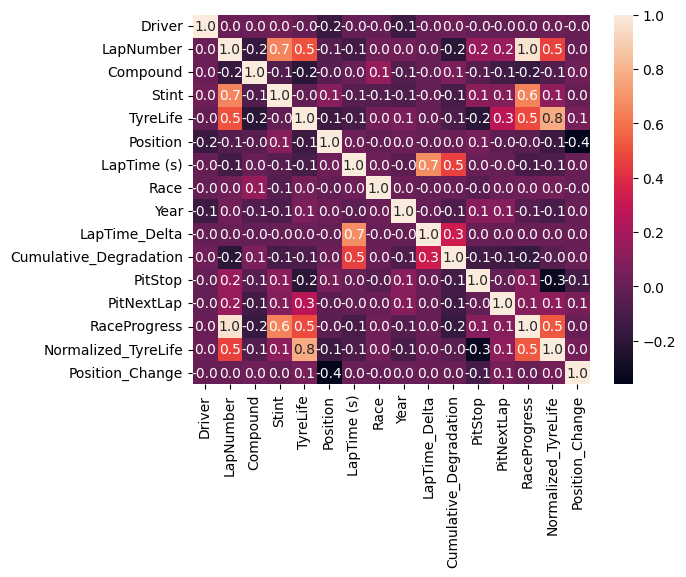

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True, fmt=".1f")

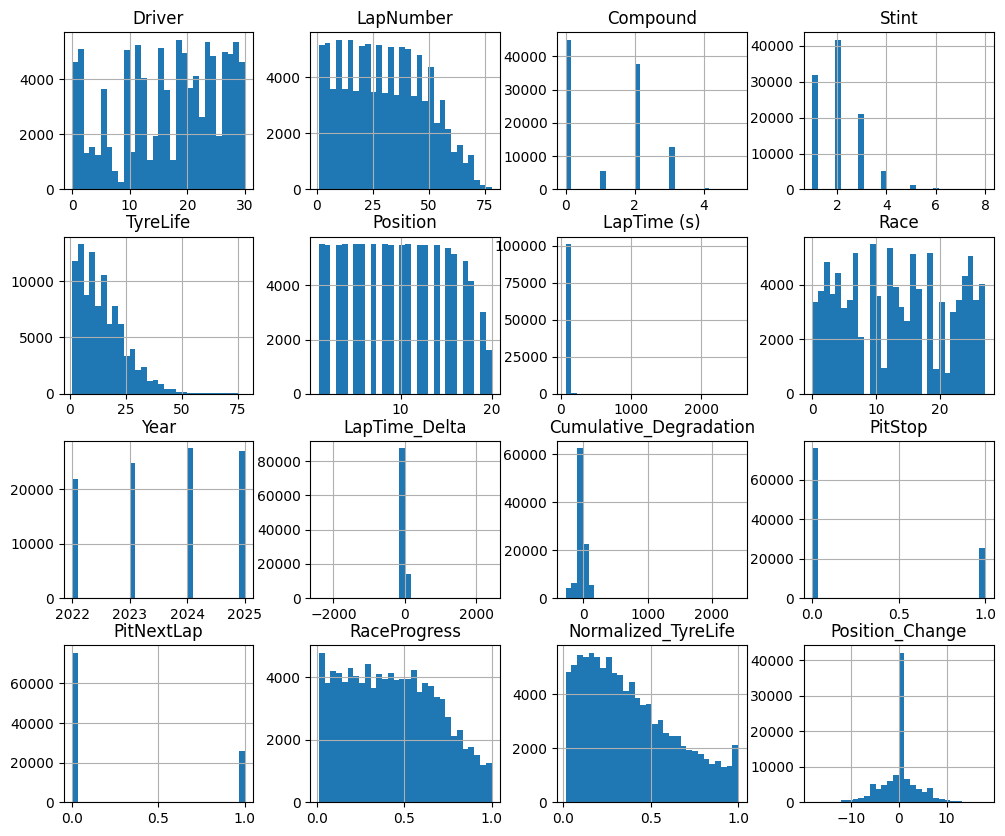

In [14]:
df.hist(figsize=(12,10), bins=30)
plt.show()

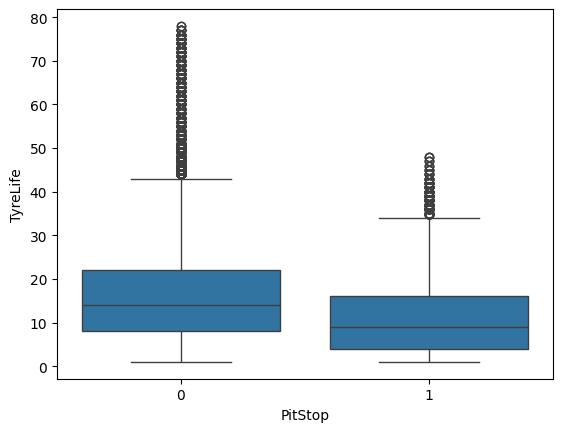

In [15]:
sns.boxplot(x="PitStop", y="TyreLife", data=df)
plt.show()

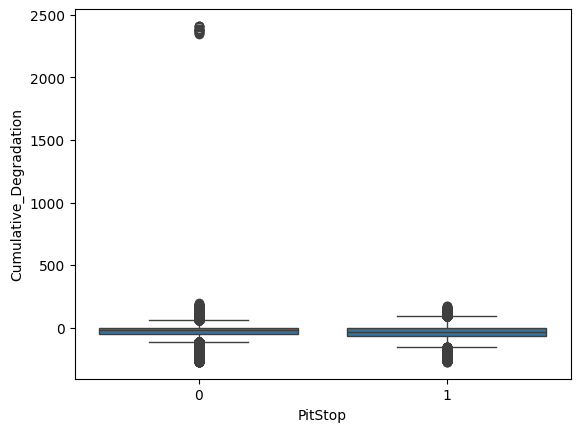

In [16]:
sns.boxplot(x="PitStop", y="Cumulative_Degradation", data=df)
plt.show()

In [17]:
lower = df["Cumulative_Degradation"].quantile(0.01)
upper = df["Cumulative_Degradation"].quantile(0.99)

df["Cumulative_Degradation"] = df["Cumulative_Degradation"].clip(lower, upper)

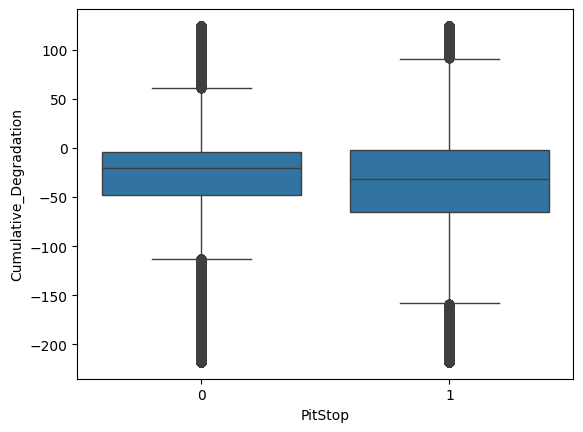

In [18]:
sns.boxplot(x="PitStop", y="Cumulative_Degradation", data=df)
plt.show()

In [19]:
x=df.drop(columns=['PitNextLap'])
y=df['PitNextLap']

In [20]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state = 42)

In [21]:
from imblearn.over_sampling import SMOTE

sm = SMOTE()

x_train, y_train = sm.fit_resample(x_train, y_train)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [23]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [24]:
model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [25]:
y_pred = model.predict(x_test)

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [29]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9452034525277435


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.96     15038
           1       0.88      0.92      0.90      5237

    accuracy                           0.95     20275
   macro avg       0.92      0.94      0.93     20275
weighted avg       0.95      0.95      0.95     20275



In [33]:
from sklearn.linear_model import LogisticRegression

In [34]:
model = LogisticRegression(
    class_weight='balanced',   
    max_iter=1000
)

In [35]:
model.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [36]:
y_pred = model.predict(x_test)

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.70      0.78     15038
           1       0.45      0.71      0.55      5237

    accuracy                           0.70     20275
   macro avg       0.66      0.70      0.66     20275
weighted avg       0.76      0.70      0.72     20275

